# Reto 05 - Detección de fraude

## Clasificación de transacciones fraudulentas con datos altamente desbalanceados

> **Fuente del problema:** [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data)
> publicado en **Kaggle** por el *Machine Learning Group* de la **Université Libre de Bruxelles (ULB)**, recopilado en colaboración
> con Worldline dentro de un proyecto de investigación sobre minería de datos y detección de fraude.

### El problema

El conjunto de datos contiene las transacciones realizadas con tarjetas de crédito por tarjetahabientes europeos durante **dos días
de septiembre de 2013**. De un total de **284,807 transacciones**, únicamente **492 son fraudulentas**, es decir, la clase positiva
representa apenas el **0.172 %** de las observaciones. Este desbalance extremo es la característica central del problema: un modelo
que clasifique todo como "legítimo" alcanzaría una exactitud superior al 99.8 % sin detectar un solo fraude, por lo que la
*accuracy* deja de ser una métrica útil y es necesario recurrir a medidas como *precision*, *recall*, *F1* o el área bajo la curva
precisión-recall (**AUPRC**).

Por razones de confidencialidad, las variables originales no están disponibles: las columnas `V1` a `V28` son las componentes
principales obtenidas mediante una transformación **PCA** sobre las características originales, y no se proporciona información
sobre su significado. Las únicas variables que conservan su escala e interpretación original son `Time` (segundos transcurridos
desde la primera transacción del conjunto) y `Amount` (monto de la transacción), lo que obliga a tratar el problema casi por
completo como uno de aprendizaje a partir de representaciones numéricas anónimas.

### Objetivo

1. Explorar el conjunto de datos y cuantificar el **desbalance de clases**.
2. Entrenar un **autoencoder** en los datos sin fraudes para que conozca como se representan y despues evaluar con fraudes para
   detectar si algún registro esta fuera del patrón de normalidad.
3. Evaluar el modelo con métricas adecuadas para clases desbalanceadas (**precision**, **recall**, **F1**, **AUC-ROC** y **AUPRC**),
   analizar la **matriz de confusión** y seleccionar un **umbral de decisión**.

### Estructura de los datos

El conjunto de datos se distribuye como un único archivo `creditcard.csv` con **284,807 filas** y **31 columnas**, todas numéricas
y sin valores faltantes:

| Columna | Tipo | Descripción |
|---|---|---|
| `Time` | float | Segundos transcurridos entre cada transacción y la primera transacción del conjunto de datos |
| `V1` … `V28` | float | Componentes principales obtenidas con PCA a partir de las características originales (anonimizadas) |
| `Amount` | float | Monto de la transacción; útil para aprendizaje sensible al costo (*cost-sensitive learning*) |
| `Class` | int | Variable objetivo: `1` para transacciones fraudulentas, `0` en caso contrario |

La combinación de un desbalance severo, variables anonimizadas y un fuerte interés práctico en no dejar pasar fraudes (a un costo
razonable de falsas alarmas) hace de este conjunto de datos un caso de estudio clásico para aprender a construir y evaluar
clasificadores en escenarios donde la clase de interés es extremadamente rara.


In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "1.0"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")


import mlflow
import keras
import pathlib
import logging
import warnings
import keras_tuner


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    roc_auc_score,
    average_precision_score,
)
from sklearn.preprocessing import StandardScaler, RobustScaler, FunctionTransformer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer

tf.get_logger().setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

warnings.filterwarnings("ignore", category=UserWarning)

AUTOTUNE = tf.data.AUTOTUNE

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("reto-05-fraud-detection")

print(
    "Keras:",
    keras.__version__,
    "| backend:",
    keras.backend.backend(),
    "| GPUs:",
    tf.config.list_physical_devices("GPU"),
)

Keras: 3.15.1 | backend: tensorflow | GPUs: []


In [2]:
seed = 42
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

In [3]:
# Read the dataset
fraud_df = pd.read_csv("../data/credit-card-fraud-detection/creditcard.csv")
fraud_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Create a boxplot on the features column
cols = [f"V{i}" for i in range(1, 29)]

In [5]:
dup = fraud_df.duplicated()

print(f"Duplicated rows: {dup.sum()}")

Duplicated rows: 1081


In [6]:
fraud_df = fraud_df.drop_duplicates()

<Axes: >

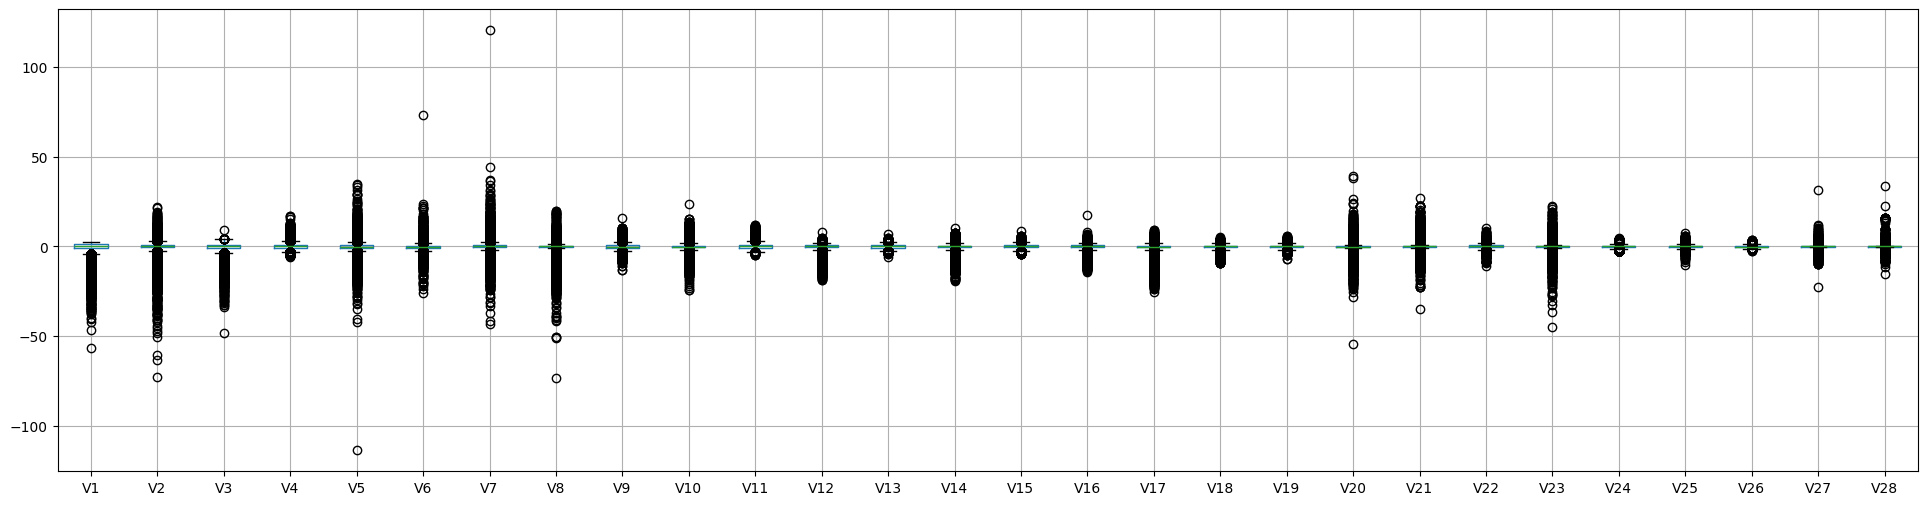

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(24, 6))
fraud_df[cols].boxplot(column=cols, ax=ax)

array([[<Axes: title={'center': 'Amount'}>]], dtype=object)

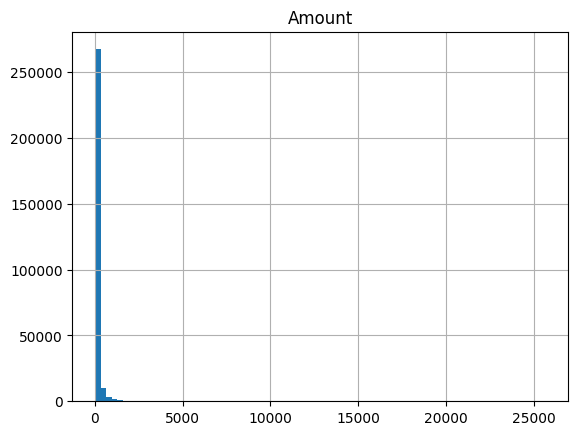

In [8]:
# Create a histogram plot on the Amount column
fraud_df[["Amount"]].hist(column=["Amount"], bins=80)

In [9]:
# Separate the features and target column
X = fraud_df.drop(columns=["Class", "Time"], inplace=False).to_numpy()
y = fraud_df["Class"].to_numpy()

In [10]:
# Create the train, test splits
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=seed,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=seed,
)

In [11]:
pipeline = make_pipeline(
    ColumnTransformer(
        transformers=[
            ("pca", RobustScaler(), [i for i in range(28)]),
            ("amount", FunctionTransformer(np.log1p), [28]),
        ]
    )
)

In [12]:
pipeline.fit(X_train, y_train)

X_train = pipeline.transform(X_train)
X_test = pipeline.transform(X_test)
X_val = pipeline.transform(X_val)

X_train_no_fraud = X_train[y_train == 0]
X_val_no_fraud = X_val[y_val == 0]

X_train_no_fraud.shape

(204649, 29)

In [13]:
def build_model(hp1, input_dim, act="relu"):
    inputs = keras.Input(shape=(input_dim,), name="inputs")

    enc_dec_dim1 = hp1.Choice("enc_dec_dim1", [32, 64, 96, 128])
    enc_dec_dim2 = hp1.Choice("enc_dec_dim2", [32, 64, 96, 128])
    emb_dim = hp1.Int("embedding_dim", min_value=4, max_value=16, step=2)
    dropout = hp1.Float(
        "dropout",
        min_value=3e-1,
        max_value=6e-1,
        step=1e-1,
        sampling="linear",
    )

    x = keras.layers.Dense(enc_dec_dim1, activation=act, name="dense_enc_1")(inputs)
    x = keras.layers.Dropout(dropout)(x)
    x = keras.layers.Dense(enc_dec_dim2, activation=act, name="dense_enc_2")(x)

    b = keras.layers.Dense(emb_dim, name="dense_emb")(x)

    d = keras.layers.Dense(enc_dec_dim2, activation=act, name="dense_dec_2")(b)
    d = keras.layers.Dropout(dropout)(d)
    d = keras.layers.Dense(enc_dec_dim1, activation=act, name="dense_dec_1")(d)
    outputs = keras.layers.Dense(input_dim, name="outputs")(d)

    model = keras.Model(inputs, outputs, name="fraud_detection")

    return model

In [14]:
EPOCHS = 25
warmup_epochs = 5

In [15]:
class LearningRateLogger(keras.callbacks.Callback):

    def on_epoch_end(self, epoch, logs={}):
        optim = self.model.optimizer  # type: ignore
        lr = optim.learning_rate
        if isinstance(lr, keras.optimizers.schedules.LearningRateSchedule):
            lr = lr(optim.iterations)
        logs["learning_rate"] = float(keras.ops.convert_to_numpy(lr))  # type: ignore

In [16]:
size, input_dim = X_train_no_fraud.shape[:2]
batch_size = 64


class Autoencoder(keras_tuner.HyperModel):

    def build(self, hp):
        # Scheduler
        steps_per_epoch = int(np.ceil(size / batch_size))
        total_steps = EPOCHS * steps_per_epoch

        warmup_steps = warmup_epochs * steps_per_epoch

        scheduler = keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=1e-5,
            warmup_target=3e-4,
            warmup_steps=warmup_steps,
            decay_steps=total_steps - warmup_steps,
            alpha=0.01,
        )

        optim_fn = keras.optimizers.Adam(learning_rate=scheduler)  # type: ignore

        model = build_model(hp, input_dim)

        model.compile(
            optimizer=optim_fn,
            loss=keras.losses.MeanSquaredError(),
        )

        return model

    def fit(self, hp, model, *args, **kwargs):
        kwargs["verbose"] = 0
        return model.fit(*args, **kwargs)

In [17]:
tuner = keras_tuner.Hyperband(
    Autoencoder(),
    objective=keras_tuner.Objective("val_loss", direction="min"),
    max_epochs=EPOCHS,
    directory="./tune",
    project_name="fraud_detection",
)

Reloading Tuner from ./tune/fraud_detection/tuner0.json


In [18]:
tuner.search(
    X_train_no_fraud,
    X_train_no_fraud,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=batch_size,
    verbose=1,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
for k in best_hp.values:
    print(f"{k}: {best_hp.get(k)}")

enc_dec_dim1: 128
enc_dec_dim2: 64
embedding_dim: 14
dropout: 0.3
tuner/epochs: 25
tuner/initial_epoch: 9
tuner/bracket: 2
tuner/round: 2
tuner/trial_id: 0012


In [19]:
def build_best_model(
    input_dim=input_dim,
    enc_dec_dim1=16,
    enc_dec_dim2=16,
    dropout=0.1,
    embedding_dim=16,
    act="relu",
    *args,
    **kwargs,
):
    inputs = keras.Input(shape=(input_dim,), name="inputs")
    x = keras.layers.Dense(enc_dec_dim1, activation=act, name="dense_enc_1")(inputs)
    x = keras.layers.Dropout(dropout)(x)
    x = keras.layers.Dense(enc_dec_dim2, activation=act, name="dense_enc_2")(x)

    b = keras.layers.Dense(embedding_dim, name="dense_emb")(x)

    d = keras.layers.Dense(enc_dec_dim2, activation=act, name="dense_dec_2")(b)
    d = keras.layers.Dropout(dropout)(d)
    d = keras.layers.Dense(enc_dec_dim1, activation=act, name="dense_dec_1")(d)
    outputs = keras.layers.Dense(input_dim, name="outputs")(d)

    model = keras.Model(inputs, outputs, name="fraud_detection")

    return model


model = build_best_model(**best_hp.values)

In [20]:
EPOCHS = 50
WARMUP_EPOCHS = 5

# Calculamos la cantidad de total de steps y ubicamos un 5% para warmup del lr
steps_per_epoch = int(np.ceil(size / batch_size))
total_steps = EPOCHS * steps_per_epoch
warmup_steps = WARMUP_EPOCHS * steps_per_epoch

scheduler = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-5,
    warmup_target=3e-4,
    warmup_steps=warmup_steps,
    decay_steps=total_steps - warmup_steps,
    alpha=0.01,
)

print(
    f"pasos/época: {steps_per_epoch} | warmup: {warmup_steps} | "
    f"decay: {total_steps - warmup_steps} | total: {total_steps}"
)

RUTA_MODELO = pathlib.Path(f"../models/reto-05-{model.name}.keras")
RUTA_MODELO.parent.mkdir(parents=True, exist_ok=True)


optim_fn = keras.optimizers.Adam(learning_rate=scheduler)  # type: ignore

stop_cb = keras.callbacks.EarlyStopping(
    patience=5,
    monitor="val_loss",
    mode="min",
    restore_best_weights=True,
)
best_cb = keras.callbacks.ModelCheckpoint(
    filepath=RUTA_MODELO,
    save_best_only=True,
    monitor="val_loss",
    mode="min",
)


class LearningRateLogger(keras.callbacks.Callback):

    def on_epoch_end(self, epoch, logs={}):
        optim = self.model.optimizer  # type: ignore
        lr = optim.learning_rate
        if isinstance(lr, keras.optimizers.schedules.LearningRateSchedule):
            lr = lr(optim.iterations)
        logs["learning_rate"] = float(keras.ops.convert_to_numpy(lr))  # type: ignore


lr_cb = LearningRateLogger()


model.compile(
    optimizer=optim_fn,
    loss=keras.losses.MeanSquaredError(),
)

with mlflow.start_run():
    mlflow.keras.autolog()
    model.fit(
        X_train_no_fraud,
        X_train_no_fraud,
        epochs=EPOCHS,
        shuffle=True,
        batch_size=batch_size,
        callbacks=[best_cb, lr_cb, stop_cb],
        validation_data=(X_val_no_fraud, X_val_no_fraud),
    )

print("Modelo guardado en:", RUTA_MODELO.resolve())

pasos/época: 3198 | warmup: 15990 | decay: 143910 | total: 159900


Epoch 1/50
3198/3198 ━━━━━━━━━━━━━━━━━━━━ 3s 610us/step - loss: 1.5811 - val_loss: 1.1427 - learning_rate: 6.8000e-05
Epoch 2/50
3198/3198 ━━━━━━━━━━━━━━━━━━━━ 2s 562us/step - loss: 0.9170 - val_loss: 0.5512 - learning_rate: 1.2600e-04
Epoch 3/50
3198/3198 ━━━━━━━━━━━━━━━━━━━━ 2s 543us/step - loss: 0.6670 - val_loss: 0.4301 - learning_rate: 1.8400e-04
Epoch 4/50
3198/3198 ━━━━━━━━━━━━━━━━━━━━ 2s 522us/step - loss: 0.5794 - val_loss: 0.3703 - learning_rate: 2.4200e-04
Epoch 5/50
3198/3198 ━━━━━━━━━━━━━━━━━━━━ 2s 551us/step - loss: 0.5161 - val_loss: 0.3243 - learning_rate: 3.0000e-04
Epoch 6/50
3198/3198 ━━━━━━━━━━━━━━━━━━━━ 2s 514us/step - loss: 0.4735 - val_loss: 0.2868 - learning_rate: 2.9964e-04
Epoch 7/50
3198/3198 ━━━━━━━━━━━━━━━━━━━━ 2s 516us/step - loss: 0.4364 - val_loss: 0.2555 - learning_rate: 2.9855e-04
Epoch 8/50
3198/3198 ━━━━━━━━━━━━━━━━━━━━ 2s 529us/step - loss: 0.4118 - val_loss: 0.2517 - learning_rate: 2.9675e-04
Epoch 9/50
3198/3198 ━━━━━━━━━━━━━━━━━━━━ 2s 505us/step 

2026/09/30 10:54:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/30 10:54:22 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run efficient-hog-427 at: http://127.0.0.1:5000/#/experiments/1/runs/096ee9a9517e49fe828202bdcdb0bab6
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Modelo guardado en: /Users/jmanuelc87/Documents/Projects/bourbaki-track-ciencia-datos/03-deep-learning/models/reto-05-fraud_detection.keras


1131/1131 ━━━━━━━━━━━━━━━━━━━━ 0s 220us/step


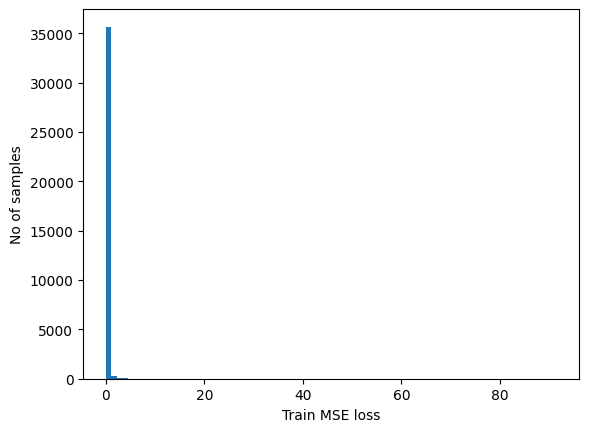

In [21]:
best_model = keras.models.load_model(RUTA_MODELO)
X_val_pred = best_model.predict(X_val)
reconstruction_error = np.mean(np.pow(X_val_pred - X_val, 2), axis=1)

plt.hist(reconstruction_error, bins=80)
plt.xlabel("Train MSE loss")
plt.ylabel("No of samples")
plt.show()

In [22]:
fpr, tpr, roc_thresholds = roc_curve(y_val, reconstruction_error)
precision, recall, pr_thresholds = precision_recall_curve(y_val, reconstruction_error)

auc_roc = roc_auc_score(y_val, reconstruction_error)
auc_pr = average_precision_score(y_val, reconstruction_error)

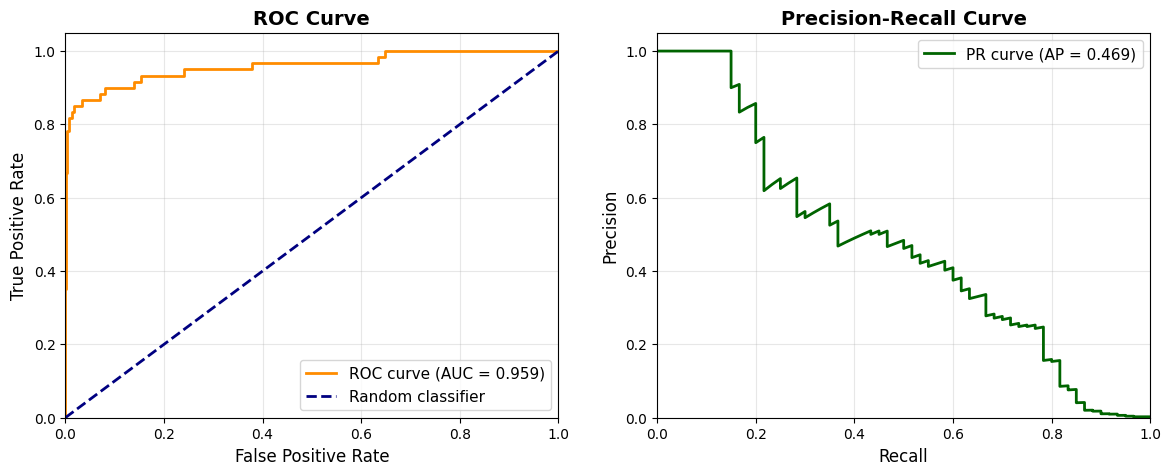

In [23]:
# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: ROC Curve
axes[0].plot(
    fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {auc_roc:.3f})"
)
axes[0].plot(
    [0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random classifier"
)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel("False Positive Rate", fontsize=12)
axes[0].set_ylabel("True Positive Rate", fontsize=12)
axes[0].set_title("ROC Curve", fontsize=14, fontweight="bold")
axes[0].legend(loc="lower right", fontsize=11)
axes[0].grid(alpha=0.3)

# Plot 2: Precision-Recall Curve
axes[1].plot(
    recall, precision, color="darkgreen", lw=2, label=f"PR curve (AP = {auc_pr:.3f})"
)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("Recall", fontsize=12)
axes[1].set_ylabel("Precision", fontsize=12)
axes[1].set_title("Precision-Recall Curve", fontsize=14, fontweight="bold")
axes[1].legend(loc="upper right", fontsize=11)
axes[1].grid(alpha=0.3)

In [ ]:
# --- Summary metrics ---
print("Autoencoder – Reconstruction Error as Anomaly Score")
print(f"Train samples:           {len(y_val):,}")
print(
    f"Fraud cases (positive): {int(np.sum(y_val)):,} "
    f"({np.mean(y_val) * 100:.3f}%)"
)
print(f"AUC-ROC:                {auc_roc:.4f}")
print(f"AUC-PR (Avg Precision): {auc_pr:.4f}")
print(f"PR baseline (random):   {np.mean(y_val):.4f}")
print(f"AUC-PR lift vs random:  {auc_pr / np.mean(y_val):.1f}x")
print(f"ROC thresholds evaluated: {len(roc_thresholds):,}")
print(f"PR thresholds evaluated:  {len(pr_thresholds):,}")
print("---")

# --- Best AUC ROC threshold ---
# Calculate Youden Index
youden_index = tpr - fpr

# Find the threshold that maximizes Youden Index
optimal_idx = np.argmax(youden_index)
optimal_threshold = roc_thresholds[optimal_idx]

print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"  TPR at optimal threshold: {tpr[optimal_idx]:.4f}")
print(f"  FPR at optimal threshold: {fpr[optimal_idx]:.4f}")


# --- Best PR threshold (max F1) ---
# precision/recall have one more element than pr_thresholds
f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)

# Get the index of the best precision
idx = np.argmax(f1_scores)
optimal_pr_threshold = pr_thresholds[idx]

print("Best threshold by F1 (Precision-Recall):")
print(f"  Threshold: {pr_thresholds[idx]:.6f}")
print(f"  Precision: {precision[idx]:.4f}")
print(f"  Recall:    {recall[idx]:.4f}")
print(f"  F1-score:  {f1_scores[idx]:.4f}")


# --- F-Beta PR Threshold (max Precision or Recall) ---
# beta = 2 favors recall, beta = 0.5 favors precision
beta = 3
fbeta_scores = (
    (1 + beta**2)
    * precision[:-1]
    * recall[:-1]
    / (beta**2 * precision[:-1] + recall[:-1] + 1e-12)
)

# Get the index of the best precision
idx = np.argmax(fbeta_scores)
optimal_fbeta_threshold = pr_thresholds[idx]

print("Best threshold by F-Beta (Precision-Recall):")
print(f"  Threshold: {pr_thresholds[idx]:.6f}")
print(f"  Precision: {precision[idx]:.4f}")
print(f"  Recall:    {recall[idx]:.4f}")
print(f"  F-Beta score:  {fbeta_scores[idx]:.4f}")

Autoencoder – Reconstruction Error as Anomaly Score
Train samples:           36,176
Fraud cases (positive): 60 (0.166%)
AUC-ROC:                0.9588
AUC-PR (Avg Precision): 0.4694
PR baseline (random):   0.0017
AUC-PR lift vs random:  283.0x
ROC thresholds evaluated: 471
PR thresholds evaluated:  35,874
---
Optimal Threshold: 0.6836
  TPR at optimal threshold: 0.8667
  FPR at optimal threshold: 0.0332
Best threshold by F1 (Precision-Recall):
  Threshold: 4.175685
  Precision: 0.4268
  Recall:    0.5833
  F1-score:  0.4930
Best threshold by F-Beta (Precision-Recall):
  Threshold: 2.101672
  Precision: 0.2474
  Recall:    0.7833
  F-Beta score:  0.6438


In [25]:
X_test_pred = best_model.predict(X_test)
reconstruction_error = np.mean(np.pow(X_test_pred - X_test, 2), axis=1)

1330/1330 ━━━━━━━━━━━━━━━━━━━━ 0s 189us/step


              precision    recall  f1-score   support

           0       1.00      0.97      0.98     42488
           1       0.04      0.80      0.08        71

    accuracy                           0.97     42559
   macro avg       0.52      0.89      0.53     42559
weighted avg       1.00      0.97      0.98     42559



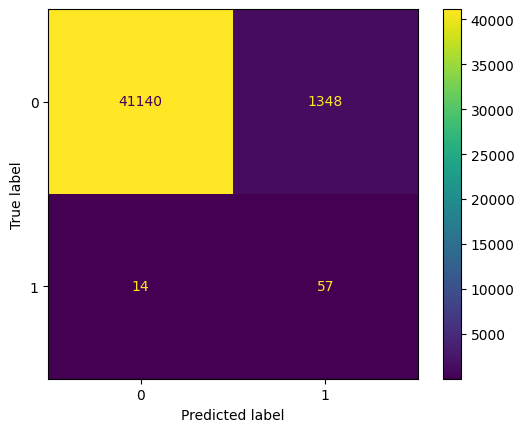

In [26]:
y_pred = (reconstruction_error > optimal_threshold).astype(int)
print(classification_report(y_test, y_pred))
ma = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(ma).plot()

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42488
           1       0.39      0.52      0.45        71

    accuracy                           1.00     42559
   macro avg       0.70      0.76      0.72     42559
weighted avg       1.00      1.00      1.00     42559



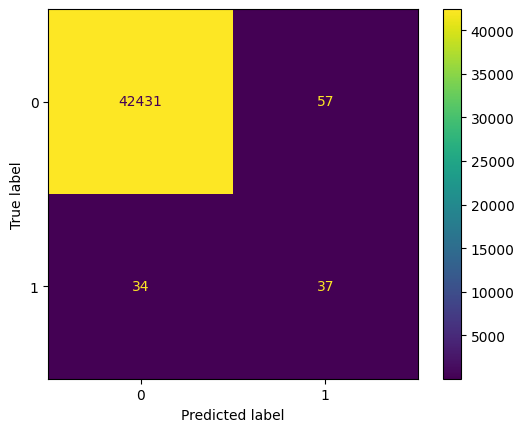

In [27]:
y_pred = (reconstruction_error > optimal_pr_threshold).astype(int)
print(classification_report(y_test, y_pred))
ma = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(ma).plot()

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42488
           1       0.24      0.75      0.37        71

    accuracy                           1.00     42559
   macro avg       0.62      0.87      0.68     42559
weighted avg       1.00      1.00      1.00     42559



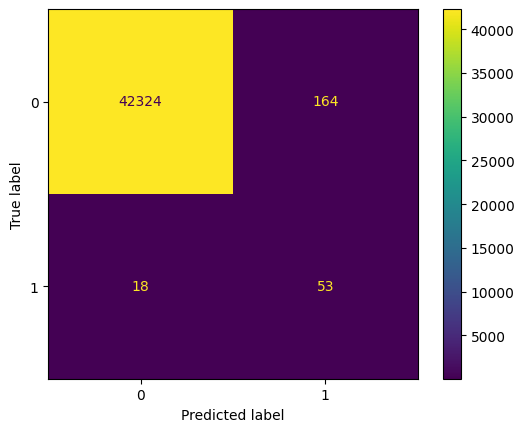

In [28]:
y_pred = (reconstruction_error > optimal_fbeta_threshold).astype(int)
print(classification_report(y_test, y_pred))
ma = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(ma).plot()

## Conclusiones

Se logro encontrar la mejor arquitectura del autoencoder, como un embudo reflejado en un espejo, usando el algoritmo Hyperband las dimensiones disminuyen hasta formar el bottleneck y despúes vuelven a aumentar hasta la misma dimensión de la entrada.

Para detectar las anomalias o fraudes primero se calcularon las curvas roc (receiver operating characteristic) y pr (precision-recall) que nos apoyan para obtener los umbrales. Los umbrales de decisión se obtuvieron con las siguientes fórmulas.

 - Youden Index: usando en los valores de la curva roc
 - F1 Score: usado en los valores de la curva pr y ofrece un balance entre precision y recall
 - F-Beta Score: usado en los valores de la curva pr y dependiendo del valor de beta se inclina hacia precision o recall


Matrices de Confusión

En la primer matriz de confusión se detectan casi todos los Fraudes pero se incrementa mucho la cantidad de FP lo que eleva el costo del trabajo manual.
En la segunda matriz bajan mucho los FP y se eleva la cantidad de FN lo que reduce la capacidad de detectar fraudes.
En la tercer matriz la detección de fraudes casi tan precisa como en la primer matriz pero se reducen de forma considerable la cantidad de FP lo que reduce el costo del trabajo manual y se mantiene baja la cantidad de FN por lo que se mantiene la capacidad de detectar fraudes.